In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.decomposition import PCA

import sys, os
sys.path.append(os.path.abspath(".."))

from data_preparation.processors import (
    RawFeatureGenerator,
    OptimizedFeatureGenerator,
    EntityEmbeddingFeatureGenerator,
)
from data_preparation.evaluator import RossmannComparer

plt.style.use("ggplot")


In [14]:
train_df = pd.read_csv("../data/train.csv", parse_dates=["Date"], low_memory=False)
store_df = pd.read_csv("../data/store.csv")

train_df = train_df[(train_df["Sales"] > 0) & (train_df["Open"] == 1)].copy()
train_df = train_df.drop(columns="Customers")

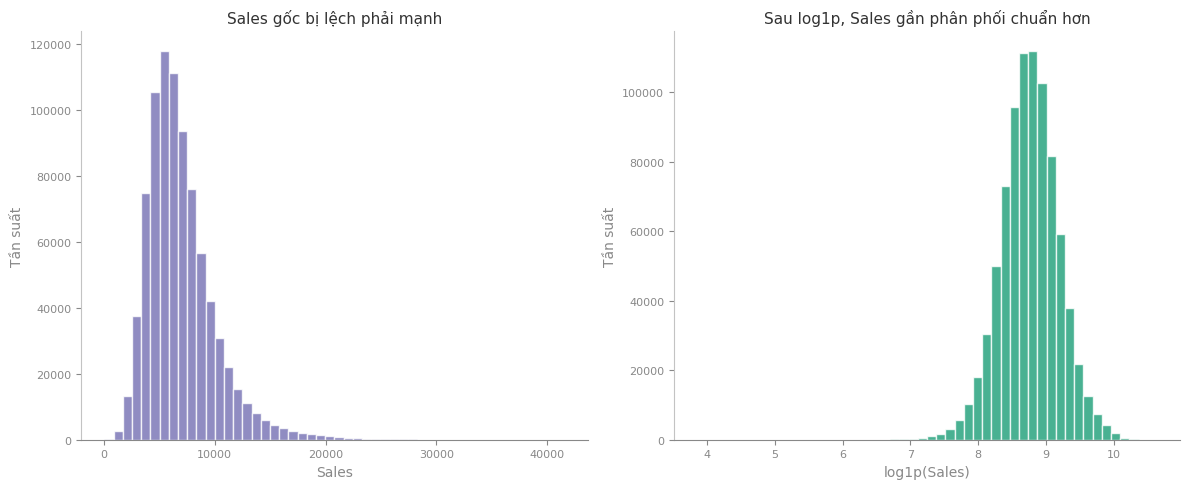

In [3]:
TEAL_BASE        = "#1B9E77"  
ORANGE_HIGHLIGHT = "#D95F02"
PURPLE_SUPPORT   = "#7570B3" 
PINK_SPECIAL     = "#E7298A"

GRAY_NEUTRAL = "#888888"
GRAY_LIGHT   = "#C3C3C3"

train_df_log_viz = train_df.copy()
train_df_log_viz["Sales_log"] = np.log1p(train_df_log_viz["Sales"])

plt.style.use("default")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor("white")

for ax in axes:
    ax.set_facecolor("white")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRAY_LIGHT)
    ax.spines["bottom"].set_color(GRAY_NEUTRAL)
    ax.grid(False)
    ax.tick_params(axis="both", labelsize=8, colors=GRAY_NEUTRAL)

axes[0].hist(
    train_df_log_viz["Sales"],
    bins=50,
    color=PURPLE_SUPPORT,
    alpha=0.8,
    edgecolor="white"
)
axes[0].set_title("Sales gốc bị lệch phải mạnh", fontsize=11, color="#333333")
axes[0].set_xlabel("Sales", fontsize=10, color=GRAY_NEUTRAL)
axes[0].set_ylabel("Tần suất", fontsize=10, color=GRAY_NEUTRAL)

axes[1].hist(
    train_df_log_viz["Sales_log"],
    bins=50,
    color=TEAL_BASE,
    alpha=0.8,
    edgecolor="white"
)
axes[1].set_title("Sau log1p, Sales gần phân phối chuẩn hơn", fontsize=11, color="#333333")
axes[1].set_xlabel("log1p(Sales)", fontsize=10, color=GRAY_NEUTRAL)
axes[1].set_ylabel("Tần suất", fontsize=10, color=GRAY_NEUTRAL)

plt.tight_layout()
plt.show()


In [4]:
FIXED_PARAMS = {
    'objective': 'reg:squarederror',
    'n_estimators': 300,
    'max_depth': 10,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'n_jobs': -1,
    'random_state': 42
}

comparer = RossmannComparer(FIXED_PARAMS, train_df, store_df)

raw_proc = RawFeatureGenerator()
opt_proc  = OptimizedFeatureGenerator()
emb_proc  = EntityEmbeddingFeatureGenerator(
    model_save_path="checkpoints/emb_model_compare.pth",
    epochs=20,
    batch_size=256,
)

raw_proc, opt_proc, emb_proc

(RawFeatureGenerator(),
 OptimizedFeatureGenerator(),
 EntityEmbeddingFeatureGenerator(batch_size=256, epochs=20,
                                 model_save_path=WindowsPath('D:/dataviz_proj/data_preparation/checkpoints/emb_model_compare.pth')))

In [5]:
rmspe_raw = comparer.evaluate("RAW_LabelEncode", raw_proc, use_log_target=False)
rmspe_opt = comparer.evaluate("Optimized_FE",   opt_proc, use_log_target=True)
rmspe_emb = comparer.evaluate("EntityEmbedding", emb_proc, use_log_target=True)

summary = comparer.get_summary()
summary



--- Evaluating: RAW_LabelEncode ---
Train range: 2013-01-01 -> 2015-06-18 (802,942 rows)
Test  range: 2015-06-19 -> 2015-07-31 (41,396 rows)
Preprocessing...
Training XGBoost (log target = False)...
Done. RMSPE: 0.16692

--- Evaluating: Optimized_FE ---
Train range: 2013-01-01 -> 2015-06-18 (802,942 rows)
Test  range: 2015-06-19 -> 2015-07-31 (41,396 rows)
Preprocessing...
Training XGBoost (log target = True)...
Optimizing correction factor (on TRAIN, not TEST)...
Best factor (from TRAIN): 0.9800
Done. RMSPE: 0.14387

--- Evaluating: EntityEmbedding ---
Train range: 2013-01-01 -> 2015-06-18 (802,942 rows)
Test  range: 2015-06-19 -> 2015-07-31 (41,396 rows)
Preprocessing...


d:\dataviz_proj\data_preparation\processors.py:544: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(str(self.model_save_path), map_location=self.device

Training XGBoost (log target = True)...
Optimizing correction factor (on TRAIN, not TEST)...
Best factor (from TRAIN): 0.9860
Done. RMSPE: 0.12380


,RMSPE,Features,Log Target
EntityEmbedding,0.123803,96,True
Optimized_FE,0.143872,20,True
RAW_LabelEncode,0.166923,17,False


In [6]:
# comparer.full_data = train_df merge với store_df
opt_features = opt_proc.transform(comparer.full_data.copy())

# Đảm bảo có cột Sales để vẽ
opt_features["Sales"] = comparer.full_data["Sales"].values

opt_features.head()


,Store,DayOfWeek,Sales,Promo,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,...,Year,Month,Day,WeekOfYear,WeekOfMonth,IsWeekend,IsStateHoliday,CompetitionMonthsOpen,Promo2Weeks,IsPromo2Month
0,1,5,5263,1,1,2,0,1270.0,9,2008,...,2015,7,31,31,5,0,0,82,0,0
1,2,5,6064,1,1,0,0,570.0,11,2007,...,2015,7,31,31,5,0,0,92,278,1
2,3,5,8314,1,1,0,0,14130.0,12,2006,...,2015,7,31,31,5,0,0,103,225,1
3,4,5,13995,1,1,2,2,620.0,9,2009,...,2015,7,31,31,5,0,0,70,0,0
4,5,5,4822,1,1,0,0,29910.0,4,2015,...,2015,7,31,31,5,0,0,3,0,0


In [7]:
from data_preparation.models import EntityEmbeddingModel

def load_trained_embedding_model(emb_processor: EntityEmbeddingFeatureGenerator) -> EntityEmbeddingModel:
    model = EntityEmbeddingModel(
        emb_processor.emb_dims,
        n_cont=len(emb_processor.cont_cols)
    )
    state_dict = torch.load(
        emb_processor.model_save_path,
        map_location=emb_processor.device
    )
    model.load_state_dict(state_dict)
    model.eval()
    return model

model_emb = load_trained_embedding_model(emb_proc)
model_emb


C:\Users\Admin\AppData\Local\Temp\ipykernel_460\2064954939.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


EntityEmbeddingModel(
  (embeddings): ModuleList(
    (0): Embedding(1115, 50)
    (1): Embedding(7, 4)
    (2): Embedding(3, 2)
    (3): Embedding(12, 6)
    (4): Embedding(31, 16)
    (5-6): 2 x Embedding(4, 2)
    (7): Embedding(3, 2)
    (8): Embedding(4, 2)
    (9): Embedding(5, 3)
  )
  (fc1): Linear(in_features=96, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=512, out_features=1, bias=True)
  (relu): ReLU()
)

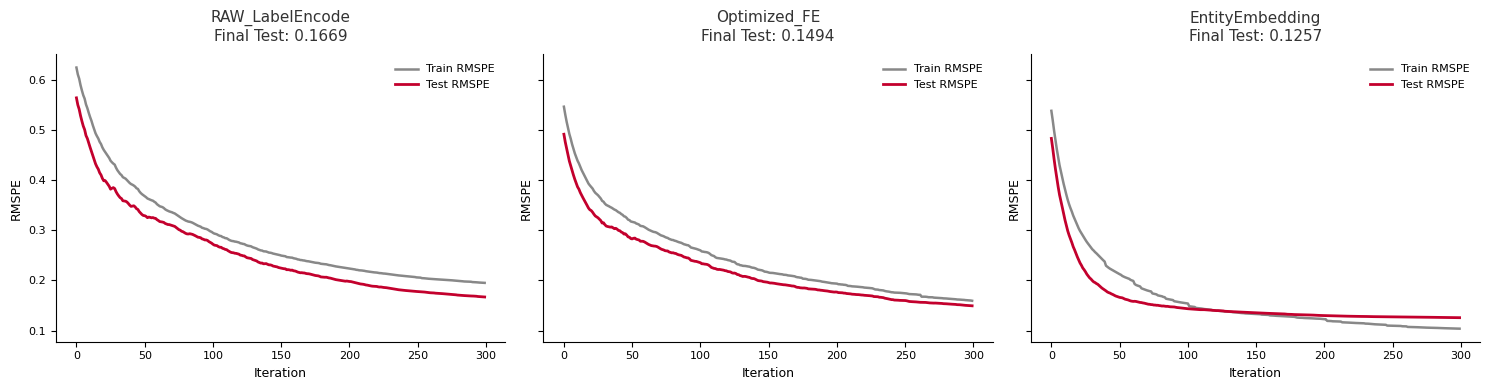

In [8]:
comparer.plot_learning_curves()


In [9]:
cat_to_W = {}
for i, col in enumerate(emb_proc.cat_cols):
    W = model_emb.embeddings[i].weight.detach().cpu().numpy()
    cat_to_W[col] = W

cat_to_W.keys()


dict_keys(['Store', 'DayOfWeek', 'Year', 'Month', 'Day', 'StateHoliday', 'StoreType', 'Assortment', 'PromoInterval', 'WeekOfMonth'])

In [10]:
# 1. Vị trí cột 'Store' trong danh sách cat_cols
store_col_idx = emb_proc.cat_cols.index("Store")

# 2. Lấy embedding matrix của 'Store' từ model đã train
W_store = model_emb.embeddings[store_col_idx].weight.detach().cpu().numpy()
# shape: (n_stores, emb_dim)

# 3. Lấy lại danh sách Store theo đúng thứ tự index của embedding
le_store = emb_proc.label_encoders["Store"]

store_ids = np.array(le_store.classes_, dtype=int)

# 4. Mean sales theo Store
mean_sales = (
    train_df
        .loc[train_df["Sales"] > 0]
        .groupby("Store", as_index=False)["Sales"]
        .mean()
        .rename(columns={"Sales": "MeanSales"})
)

# 5. Ghép embedding + mean_sales
emb_cols = [f"Store_emb_{i}" for i in range(W_store.shape[1])]
df_store_emb = pd.DataFrame(W_store, columns=emb_cols)
df_store_emb.insert(0, "Store", store_ids)

store_emb_with_sales = df_store_emb.merge(mean_sales, on="Store", how="left")


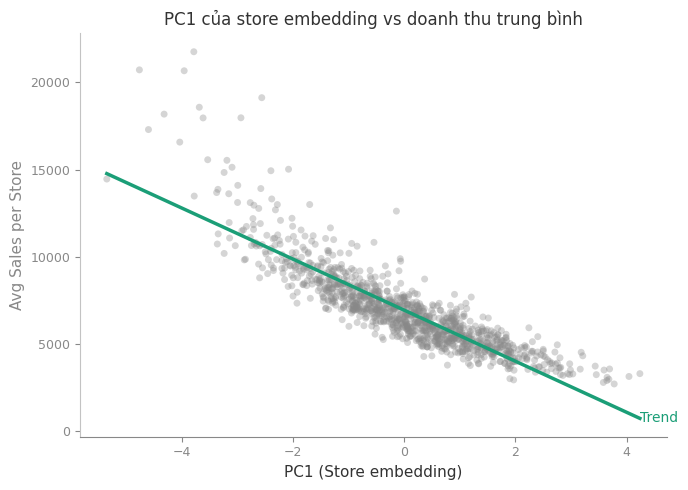

In [11]:
# =======palette =======
TEAL_BASE        = "#1B9E77"  # Đường xu hướng chính / baseline
ORANGE_HIGHLIGHT = "#D95F02"  # Dùng cho nhóm cần nhấn mạnh (nếu thêm)
PURPLE_SUPPORT   = "#7570B3"  # Nhóm bổ sung
PINK_SPECIAL     = "#E7298A"  # Nhóm đặc biệt / outlier

GRAY_DOT     = "#888888"
GRAY_NEUTRAL = "#888888"
GRAY_LIGHT   = "#C3C3C3"

# PCA cho store embedding
pca_store = PCA(n_components=4)
store_pcs = pca_store.fit_transform(W_store)

pc_df = pd.DataFrame({
    "Store": store_ids,
    "PC1": store_pcs[:, 0],
    "PC2": store_pcs[:, 1],
})
pc_df = pc_df.merge(mean_sales, on="Store", how="left")

plt.style.use("default")

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.scatter(
    pc_df["PC1"], pc_df["MeanSales"],
    alpha=0.35,
    s=25,
    color=GRAY_DOT,
    edgecolors="none"
)

coef = np.polyfit(pc_df["PC1"], pc_df["MeanSales"], deg=1)
x_line = np.linspace(pc_df["PC1"].min(), pc_df["PC1"].max(), 100)
y_line = coef[0] * x_line + coef[1]
ax.plot(
    x_line, y_line,
    linestyle="-",
    linewidth=2.5,
    color=TEAL_BASE
)

ax.text(
    x_line[-1],
    y_line[-1],
    "Trend",
    color=TEAL_BASE,
    fontsize=10,
    va="center",
    ha="left"
)

# Trục & title gọn
ax.set_xlabel("PC1 (Store embedding)", fontsize=11, color="#333333")
ax.set_ylabel("Avg Sales per Store", fontsize=11, color=GRAY_NEUTRAL)
ax.set_title("PC1 của store embedding vs doanh thu trung bình", fontsize=12, color="#333333")

# Declutter
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRAY_LIGHT)
ax.spines["bottom"].set_color(GRAY_NEUTRAL)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_NEUTRAL)

plt.tight_layout()
plt.show()


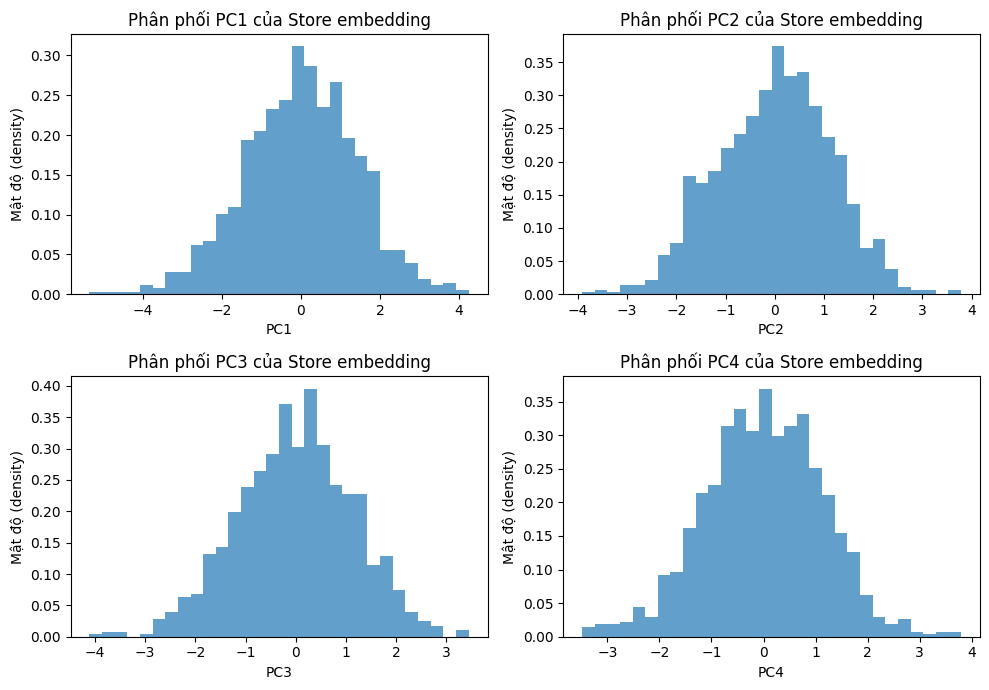

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))

for i in range(4):
    ax = axes.flat[i]
    ax.hist(store_pcs[:, i], bins=30, density=True, alpha=0.7)
    ax.set_title(f"Phân phối PC{i+1} của Store embedding")
    ax.set_xlabel(f"PC{i+1}")
    ax.set_ylabel("Mật độ (density)")

plt.tight_layout()
plt.show()


Embedding Store shape: (1115, 50), #stores = 1115
log_mean_sales range: 7.902759801285105 -> 9.987759002693922
Số cặp dùng để vẽ: 9988


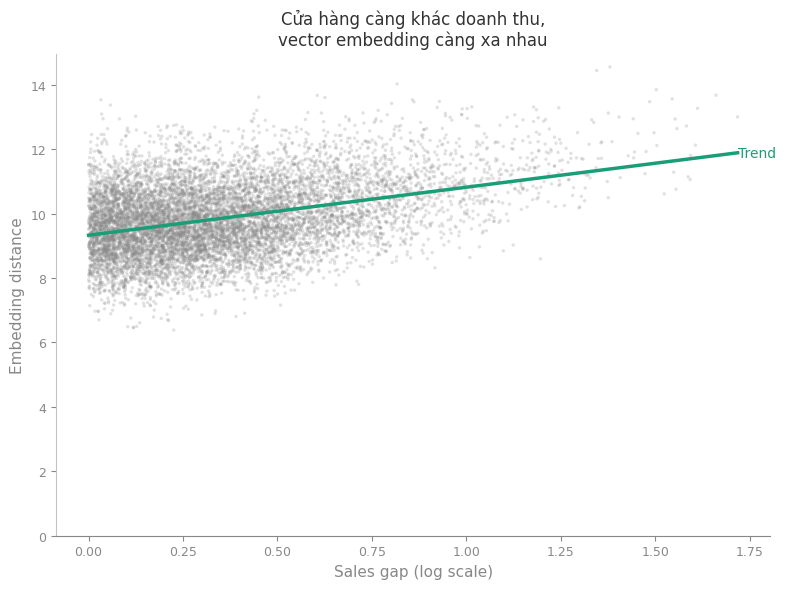

In [13]:
# 1. Lấy embedding và thứ tự store bên trong embedding
store_idx = emb_proc.cat_cols.index("Store")
W_store   = model_emb.embeddings[store_idx].weight.detach().cpu().numpy()  # (n_stores, emb_dim)

le_store  = emb_proc.label_encoders["Store"]
store_ids = le_store.classes_.astype(int)   # ID Store gốc tương ứng với từng hàng trong W_store

n_stores, emb_dim = W_store.shape
print(f"Embedding Store shape: {W_store.shape}, #stores = {n_stores}")

# 2. Tính metric value = log1p(mean Sales) per Store
mean_sales = comparer.full_data.groupby("Store")["Sales"].mean()
log_mean_sales = np.log1p(mean_sales)   # thu nhỏ thang đo

# Sắp xếp metric theo đúng thứ tự store_ids (khớp với W_store)
log_metric_vals = log_mean_sales.loc[store_ids].values  # shape (n_stores,)

print("log_mean_sales range:", log_metric_vals.min(), "->", log_metric_vals.max())

# 3. Lấy 10 000 cặp store ngẫu nhiên & tính khoảng cách
N_PAIRS = 10_000
rng = np.random.default_rng(42)

i_idx = rng.integers(0, n_stores, size=N_PAIRS)
j_idx = rng.integers(0, n_stores, size=N_PAIRS)

mask = i_idx != j_idx
i_idx = i_idx[mask]
j_idx = j_idx[mask]
print("Số cặp dùng để vẽ:", len(i_idx))

# distance trong metric space = |log_sales_i - log_sales_j|
metric_dists = np.abs(log_metric_vals[i_idx] - log_metric_vals[j_idx])

# distance trong embedding space = ||e_i - e_j||_2
embed_dists = np.linalg.norm(W_store[i_idx] - W_store[j_idx], axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# 1) Scatter: background xám, rất nhạt
ax.scatter(
    metric_dists,
    embed_dists,
    s=6,
    alpha=0.25,
    color=GRAY_DOT,
    edgecolors="none"
)

# 2) Đường xu hướng: dùng TEAL_BASE 
coef = np.polyfit(metric_dists, embed_dists, deg=1)
x_line = np.linspace(metric_dists.min(), metric_dists.max(), 200)
y_line = coef[0] * x_line + coef[1]

ax.plot(
    x_line,
    y_line,
    linestyle="-",
    linewidth=2.5,
    color=TEAL_BASE
)

ax.text(
    x_line[-1],
    y_line[-1],
    "Trend",
    color=TEAL_BASE,
    fontsize=10,
    va="center",
    ha="left"
)

# 3) Text tối giản
ax.set_ylim(bottom=0)
ax.set_xlabel("Sales gap (log scale)", fontsize=11, color=GRAY_NEUTRAL)
ax.set_ylabel("Embedding distance", fontsize=11, color=GRAY_NEUTRAL)
ax.set_title(
    "Cửa hàng càng khác doanh thu,\nvector embedding càng xa nhau",
    fontsize=12,
    color="#333333"
)

# Declutter
ax.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(GRAY_LIGHT)
ax.spines["bottom"].set_color(GRAY_NEUTRAL)
ax.tick_params(axis="both", labelsize=9, colors=GRAY_NEUTRAL)

plt.tight_layout()
plt.show()
